In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

In [2]:
# Example with sample data
df = pd.read_csv('data/02-14-2018.csv')

In [9]:
# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset shape: (1044751, 80)

Column names:
['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', '

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign


In [10]:
print("\nDataset info:")
print(df.info())
print("\nBasic statistics:")
print(df.describe())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
Index: 1044751 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1044751 non-null  int64  
 1   Protocol           1044751 non-null  int64  
 2   Timestamp          1044751 non-null  object 
 3   Flow Duration      1044751 non-null  int64  
 4   Tot Fwd Pkts       1044751 non-null  int64  
 5   Tot Bwd Pkts       1044751 non-null  int64  
 6   TotLen Fwd Pkts    1044751 non-null  int64  
 7   TotLen Bwd Pkts    1044751 non-null  int64  
 8   Fwd Pkt Len Max    1044751 non-null  int64  
 9   Fwd Pkt Len Min    1044751 non-null  int64  
 10  Fwd Pkt Len Mean   1044751 non-null  float64
 11  Fwd Pkt Len Std    1044751 non-null  float64
 12  Bwd Pkt Len Max    1044751 non-null  int64  
 13  Bwd Pkt Len Min    1044751 non-null  int64  
 14  Bwd Pkt Len Mean   1044751 non-null  float64
 15  Bwd Pkt Len Std    104

In [11]:
# Check for missing values
print(f"Missing values: {df.isnull().sum().sum()}")
print("\nMissing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

Missing values: 0

Missing values per column:
Series([], dtype: int64)


In [12]:
# Check for infinite values
print(f"\nInfinite values: {np.isinf(df.select_dtypes(include=[np.number])).sum().sum()}")


Infinite values: 0


In [13]:
# Check class distribution
print("\nClass distribution:")
print(df['Label'].value_counts())


Class distribution:
Label
Benign            663808
FTP-BruteForce    193354
SSH-Bruteforce    187589
Name: count, dtype: int64


In [14]:
# Make a copy of the dataset
data = df.copy()

# Handle missing values for numeric columns
numeric_cols = data.select_dtypes(include=[np.number]).columns
print(f"Numeric columns: {len(numeric_cols)}")

# Fill missing values with median
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

# Handle infinite values
data = data.replace([np.inf, -np.inf], np.nan)
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

print("Missing values after cleaning:", data.isnull().sum().sum())
print("Infinite values after cleaning:", np.isinf(data.select_dtypes(include=[np.number])).sum().sum())

Numeric columns: 78
Missing values after cleaning: 0
Infinite values after cleaning: 0


In [15]:
# Separate features and target
X = data.drop('Label', axis=1)
y = data['Label']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {X.columns.tolist()}")

Features shape: (1044751, 79)
Target shape: (1044751,)
Feature columns: ['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Si

In [16]:
# Check for categorical columns
categorical_columns = X.select_dtypes(include=['object']).columns
print(f"Categorical columns: {categorical_columns.tolist()}")

# Encode categorical variables if any
for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    print(f"Encoded {col}")

# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\nClasses: {label_encoder.classes_}")
print(f"Number of classes: {len(label_encoder.classes_)}")

Categorical columns: ['Timestamp']
Encoded Timestamp

Classes: ['Benign' 'FTP-BruteForce' 'SSH-Bruteforce']
Number of classes: 3


In [17]:
# Display class distribution after encoding
unique, counts = np.unique(y_encoded, return_counts=True)
for i, (class_idx, count) in enumerate(zip(unique, counts)):
    print(f"Class {class_idx} ({label_encoder.classes_[class_idx]}): {count} samples")


Class 0 (Benign): 663808 samples
Class 1 (FTP-BruteForce): 193354 samples
Class 2 (SSH-Bruteforce): 187589 samples


In [18]:
# First split: separate test set (80% train+val, 20% test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Second split: separate train and validation (64% train, 16% val, 20% test)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

# Convert to float32 for TabNet
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

print("\nData types after conversion:")
print(f"X_train dtype: {X_train.dtypes.iloc[0]}")
print("Data split completed!")

Training set: (668640, 79)
Validation set: (167160, 79)
Test set: (208951, 79)

Data types after conversion:
X_train dtype: float32
Data split completed!


In [21]:
# Initialize TabNet
clf = TabNetClassifier(
    cat_emb_dim=1,
    n_d=8,              # Width of decision prediction layer
    n_a=8,              # Width of attention embedding
    n_steps=3,          # Number of decision steps
    gamma=1.3,          # Coefficient for feature reusage in successive steps
    lambda_sparse=1e-3, # Sparsity regularization
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type="sparsemax",
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=1
)

In [22]:
print("Starting TabNet model training...")
print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Features: {X_train.shape[1]}")


Starting TabNet model training...
Training samples: 668640
Validation samples: 167160
Features: 79


In [26]:
# Train the model
clf.fit(
    X_train=X_train.values, y_train=y_train,
    max_epochs=100,
    patience=15,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False,
    eval_metric=['auc', 'accuracy']
)



c:\Users\YOGA\Desktop\master s4 PFE\project\IDS-MAS\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 0.02152 |  0:00:51s
epoch 1  | loss: 0.00095 |  0:01:40s
epoch 2  | loss: 0.00155 |  0:02:28s
epoch 3  | loss: 0.00067 |  0:03:16s
epoch 4  | loss: 0.00202 |  0:04:05s
epoch 5  | loss: 0.00051 |  0:04:53s
epoch 6  | loss: 0.00089 |  0:05:41s
epoch 7  | loss: 0.00129 |  0:06:29s
epoch 8  | loss: 0.00048 |  0:07:15s
epoch 9  | loss: 0.00297 |  0:08:03s
epoch 10 | loss: 0.0003  |  0:08:51s
epoch 11 | loss: 0.0005  |  0:09:56s
epoch 12 | loss: 0.00164 |  0:10:56s
epoch 13 | loss: 0.00072 |  0:11:59s
epoch 14 | loss: 0.00152 |  0:13:11s
epoch 15 | loss: 0.00029 |  0:14:19s
epoch 16 | loss: 0.00021 |  0:15:14s
epoch 17 | loss: 0.00047 |  0:16:03s
epoch 18 | loss: 0.00124 |  0:16:44s
epoch 19 | loss: 0.00038 |  0:17:25s
epoch 20 | loss: 0.00025 |  0:18:06s
epoch 21 | loss: 0.00044 |  0:18:47s
epoch 22 | loss: 0.00035 |  0:19:29s
epoch 23 | loss: 0.00027 |  0:20:11s
epoch 24 | loss: 0.00016 |  0:20:53s
epoch 25 | loss: 0.00023 |  0:21:35s
epoch 26 | loss: 0.00014 |  0:22:15s
e

In [37]:
# Make predictions on test set
print("Making predictions on test set...")
y_pred = clf.predict(X_test.values)
y_pred_proba = clf.predict_proba(X_test.values)

print(f"Predictions shape: {y_pred.shape}")
print(f"Prediction probabilities shape: {y_pred_proba.shape}")
print("Predictions completed!")

Making predictions on test set...
Predictions shape: (208951,)
Prediction probabilities shape: (208951, 3)
Predictions completed!


In [41]:
# Evaluate
accuracy = accuracy_score(y_test, y_pred)
# auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"Accuracy: {accuracy:.4f}")
# print(f"AUC: {auc:.4f}")

Accuracy: 0.8204


In [42]:
# Calculate accuracy
from sklearn.metrics import classification_report, confusion_matrix


accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Calculate AUC
if len(label_encoder.classes_) == 2:
    auc = roc_auc_score(y_test, y_pred_proba[:, 1])
    print(f"\nAUC Score: {auc:.4f}")
else:
    auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
    print(f"\nAUC Score (OvR): {auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)

Test Accuracy: 0.8204

Classification Report:
                precision    recall  f1-score   support

        Benign       0.78      1.00      0.88    132762
FTP-BruteForce       1.00      1.00      1.00     38671
SSH-Bruteforce       0.00      0.00      0.00     37518

      accuracy                           0.82    208951
     macro avg       0.59      0.67      0.63    208951
  weighted avg       0.68      0.82      0.74    208951



c:\Users\YOGA\Desktop\master s4 PFE\project\IDS-MAS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\YOGA\Desktop\master s4 PFE\project\IDS-MAS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\YOGA\Desktop\master s4 PFE\project\IDS-MAS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war


AUC Score (OvR): 1.0000

Confusion Matrix:
[[132762      0      0]
 [     0  38671      0]
 [ 37518      0      0]]


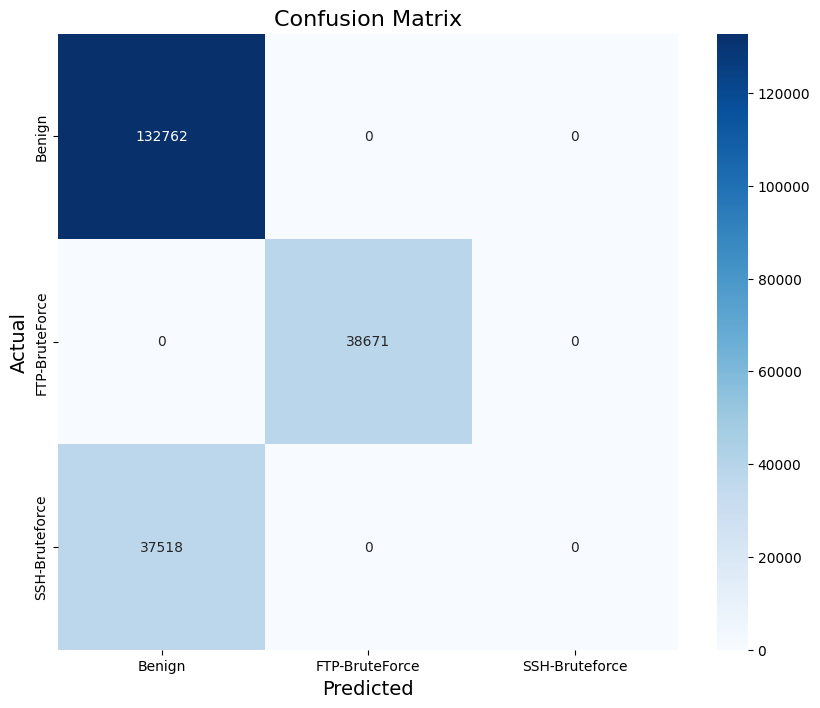

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Actual', fontsize=14)
plt.xlabel('Predicted', fontsize=14)
plt.show()

KeyError: 'train_loss'

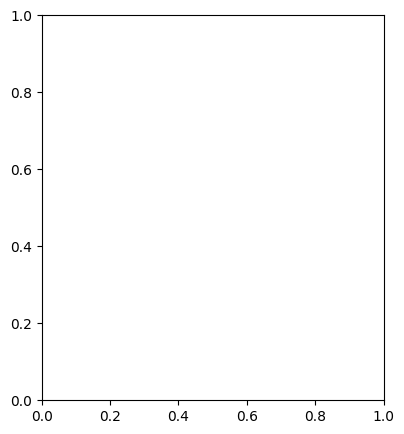

In [44]:
# Plot training history
plt.figure(figsize=(15, 5))

# Training and validation loss
plt.subplot(1, 3, 1)
plt.plot(clf.history['train_loss'], label='Training Loss', color='blue')
plt.plot(clf.history['valid_loss'], label='Validation Loss', color='red')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Training and validation accuracy
plt.subplot(1, 3, 2)
if 'train_accuracy' in clf.history:
    plt.plot(clf.history['train_accuracy'], label='Training Accuracy', color='blue')
    plt.plot(clf.history['valid_accuracy'], label='Validation Accuracy', color='red')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

# Training and validation AUC
plt.subplot(1, 3, 3)
if 'train_auc' in clf.history:
    plt.plot(clf.history['train_auc'], label='Training AUC', color='blue')
    plt.plot(clf.history['valid_auc'], label='Validation AUC', color='red')
    plt.title('Model AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [45]:
# Get feature importance from TabNet
feature_importance = clf.feature_importances_
print(f"Feature importance shape: {feature_importance.shape}")

# Create a DataFrame for better analysis
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(importance_df.head(10))

Feature importance shape: (79,)
Top 10 Most Important Features:
             feature  importance
0           Dst Port    0.417205
24       Fwd IAT Std    0.312928
46      SYN Flag Cnt    0.149367
60    Bwd Byts/b Avg    0.059320
48      PSH Flag Cnt    0.052397
10  Fwd Pkt Len Mean    0.008777
43       Pkt Len Std    0.000006
6    TotLen Fwd Pkts    0.000000
7    TotLen Bwd Pkts    0.000000
8    Fwd Pkt Len Max    0.000000


C:\Users\YOGA\AppData\Local\Temp\ipykernel_12840\485927845.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20, x='importance', y='feature', palette='viridis')


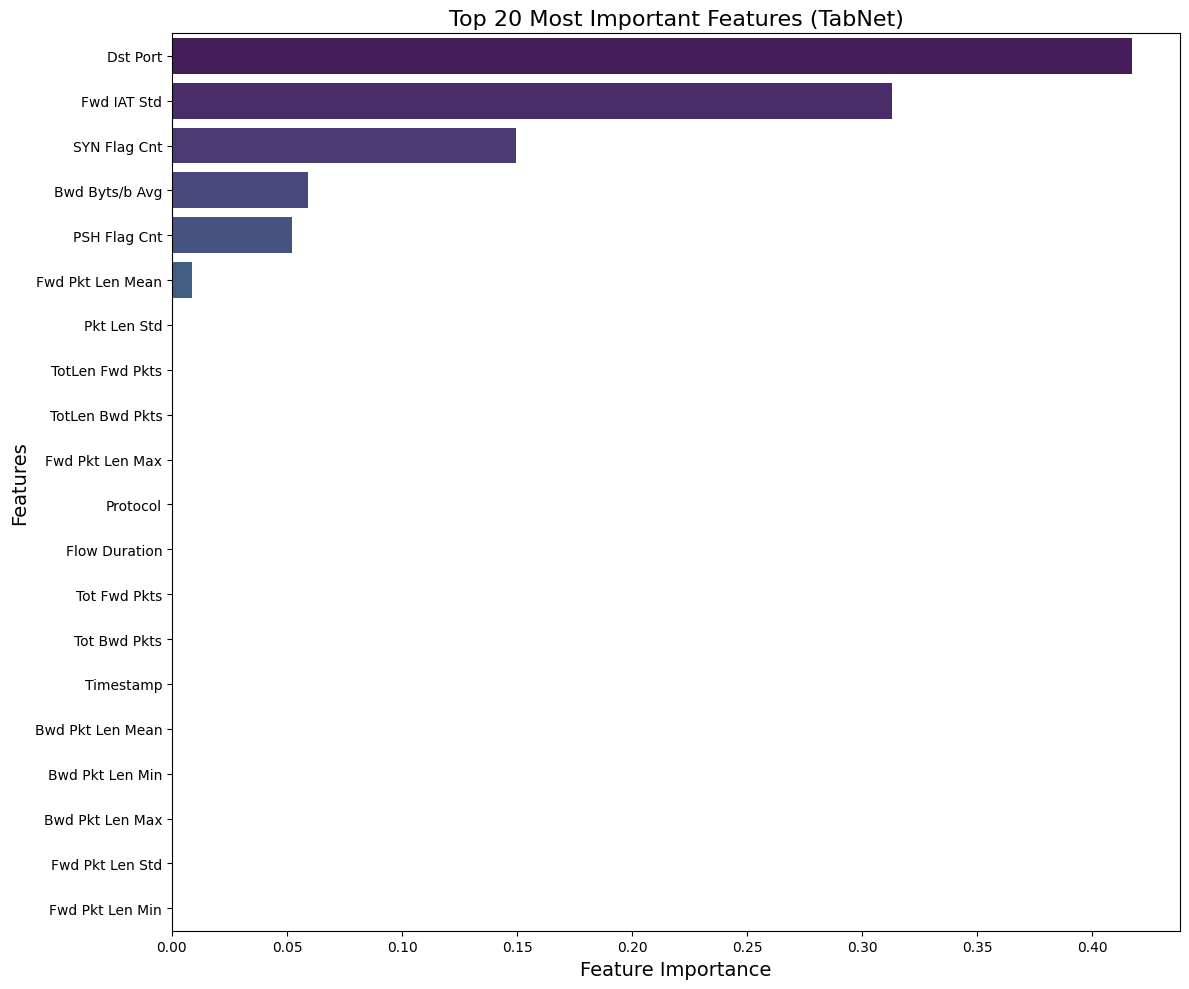

In [46]:
# Plot top 20 most important features
plt.figure(figsize=(12, 10))
top_20 = importance_df.head(20)
sns.barplot(data=top_20, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Most Important Features (TabNet)', fontsize=16)
plt.xlabel('Feature Importance', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

# Plot all features (if manageable number)
if len(importance_df) <= 50:
    plt.figure(figsize=(12, len(importance_df) * 0.3))
    sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
    plt.title('All Features Importance (TabNet)', fontsize=16)
    plt.xlabel('Feature Importance', fontsize=14)
    plt.ylabel('Features', fontsize=14)
    plt.tight_layout()
    plt.show()

In [47]:
# Analyze performance per class
for i, class_name in enumerate(label_encoder.classes_):
    class_mask = (y_test == i)
    class_accuracy = accuracy_score(y_test[class_mask], y_pred[class_mask])
    class_count = np.sum(class_mask)
    
    print(f"Class {i} ({class_name}):")
    print(f"  Samples: {class_count}")
    print(f"  Accuracy: {class_accuracy:.4f}")
    print()

# Prediction distribution
print("Prediction Distribution:")
pred_unique, pred_counts = np.unique(y_pred, return_counts=True)
for class_idx, count in zip(pred_unique, pred_counts):
    print(f"  Predicted as {label_encoder.classes_[class_idx]}: {count} samples")

Class 0 (Benign):
  Samples: 132762
  Accuracy: 1.0000

Class 1 (FTP-BruteForce):
  Samples: 38671
  Accuracy: 1.0000

Class 2 (SSH-Bruteforce):
  Samples: 37518
  Accuracy: 0.0000

Prediction Distribution:
  Predicted as Benign: 170280 samples
  Predicted as FTP-BruteForce: 38671 samples


In [ ]:
# Save the trained model
clf.save_model('tabnet_network_model')
print("Model saved as 'tabnet_network_model.zip'")

# Save feature importance
importance_df.to_csv('feature_importance.csv', index=False)
print("Feature importance saved as 'feature_importance.csv'")

# Create and save detailed results
results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'actual_label': [label_encoder.classes_[i] for i in y_test],
    'predicted_label': [label_encoder.classes_[i] for i in y_pred]
})

# Add prediction probabilities for each class
for i, class_name in enumerate(label_encoder.classes_):
    results_df[f'prob_{class_name}'] = y_pred_proba[:, i]

results_df.to_csv('detailed_predictions.csv', index=False)
print("Detailed predictions saved as 'detailed_predictions.csv'")

# Save model performance summary
summary = {
    'accuracy': accuracy,
    'auc': auc,
    'n_classes': len(label_encoder.classes_),
    'n_features': X.shape[1],
    'n_train_samples': X_train.shape[0],
    'n_test_samples': X_test.shape[0]
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv('model_summary.csv', index=False)
print("Model summary saved as 'model_summary.csv'")

In [48]:
print("="*60)
print("TABNET MODEL TRAINING COMPLETED")
print("="*60)
print(f"Final Test Accuracy: {accuracy:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Number of Classes: {len(label_encoder.classes_)}")
print(f"Number of Features: {X.shape[1]}")
print(f"Training Samples: {X_train.shape[0]}")
print(f"Test Samples: {X_test.shape[0]}")
print("\nClasses:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {i}: {class_name}")
print("\nFiles saved:")
print("  - tabnet_network_model.zip")
print("  - feature_importance.csv")
print("  - detailed_predictions.csv")
print("  - model_summary.csv")
print("="*60)

TABNET MODEL TRAINING COMPLETED
Final Test Accuracy: 0.8204
AUC Score: 1.0000
Number of Classes: 3
Number of Features: 79
Training Samples: 668640
Test Samples: 208951

Classes:
  0: Benign
  1: FTP-BruteForce
  2: SSH-Bruteforce

Files saved:
  - tabnet_network_model.zip
  - feature_importance.csv
  - detailed_predictions.csv
  - model_summary.csv
